# Kruskal's Minimum Spanning Tree Algorithm

**Domain:** `data-structures-algorithms`

Imagine you run a telecom company that needs to connect a handful of small
towns with fiber-optic cable. Every possible pair of towns *could*, in
principle, be connected directly - but running cable is expensive per mile,
and you don't need to connect every pair directly. You just need every town
to be reachable from every other town, one way or another, over the network
you build. And you definitely don't want to pay for a stretch of cable that's
redundant: a loop where you could cut any one segment and every town would
still reach every other town just fine through the rest of the network.

So the real goal is narrower than "connect everything to everything": build
the network that reaches every town using **no more cable than necessary**,
at the **lowest possible total cost**.

That's the **minimum spanning tree (MST)** problem: given a set of locations
and the cost of connecting each possible pair, find the cheapest set of
connections that reaches every location, with zero redundant connections.

**Kruskal's algorithm** solves it with a strikingly simple greedy strategy:
look at every possible cable segment, cheapest first, and lay it down
*unless* it would create a redundant loop with cable you've already
committed to.

By the end of this tutorial you'll be able to: explain why greedily grabbing
the cheapest edge is always safe, prove it using the **cut property**,
derive the algorithm's running time, watch it run step by step on a small
graph, and run a real, compiled C++ implementation - backed by a
from-scratch **union-find** (disjoint-set) data structure - that reports its
own edge-acceptance statistics and timing.

## The idea, intuitively

**Two rules, and that's the whole algorithm:**

- **Sort every possible edge (road/cable) by cost, cheapest first.**
- **Walk through them in that order. Add an edge to your growing network
  UNLESS its two endpoints are already connected** - directly or
  indirectly, through edges you've already added. If they're already
  connected, this edge would only create a wasteful loop (a **cycle**), so
  skip it (reject it).
- **Stop once you've added exactly (number of towns - 1) edges.** That's
  always enough to connect every town with zero redundancy - a structure
  called a **spanning tree**.

Let's trace it by hand on 7 towns, `A` through `G`, connected by roads of
various costs:

```
A-B: 4      A-C: 2      B-C: 1      B-D: 5
C-D: 8      C-E: 10     D-E: 2      D-F: 6
E-F: 3      E-G: 1      F-G: 7
```

**Step 1 - sort every edge by cost, cheapest first:**

```
B-C:1   E-G:1   A-C:2   D-E:2   E-F:3   A-B:4   B-D:5   D-F:6   F-G:7   C-D:8   C-E:10
```

**Step 2 - walk through them in that order:**

- `B-C` (cost 1): B and C aren't connected yet &rarr; **accept**. Network so
  far: `{B-C}`.
- `E-G` (cost 1): E and G aren't connected yet &rarr; **accept**. Network:
  `{B-C, E-G}`.
- `A-C` (cost 2): A and C aren't connected yet (C is only linked to B so
  far) &rarr; **accept**. Component `{A, B, C}` forms.
- `D-E` (cost 2): D and E aren't connected yet &rarr; **accept**. Component
  `{D, E, G}` forms.
- `E-F` (cost 3): E and F aren't connected yet (F is on its own so far)
  &rarr; **accept**. Component grows to `{D, E, F, G}`.
- `A-B` (cost 4): A and B are **already** connected - both are in
  `{A, B, C}` &rarr; **reject**. Adding this edge would only close a loop
  inside a component that's already fully reachable.
- `B-D` (cost 5): B is in `{A, B, C}`, D is in `{D, E, F, G}` - not
  connected yet &rarr; **accept**. Everything merges into one component:
  `{A, B, C, D, E, F, G}`. That's **6 accepted edges for 7 towns** - exactly
  `n - 1`. Stop here; the remaining edges (`D-F`, `F-G`, `C-D`, `C-E`) are
  never even examined.

**Total cost: 1 + 1 + 2 + 2 + 3 + 5 = 14.**

Notice the pattern: every rejected edge was rejected for exactly one
reason - its endpoints were already reachable from each other. Here's that
exact process as real, runnable Python, using the simplest possible
"are these two nodes already connected?" check (a list of sets we scan
linearly) - not yet the efficient union-find structure the real
implementation uses, but the identical greedy logic:

In [1]:
def same_component(components, u, v):
    for comp in components:
        if u in comp and v in comp:
            return True
    return False

def toy_kruskal(vertices, edges):
    components = [{v} for v in vertices]
    edges_sorted = sorted(edges, key=lambda e: e[2])
    mst = []
    log = []
    for u, v, w in edges_sorted:
        if same_component(components, u, v):
            log.append(f"reject {u}-{v} (w={w}): already connected")
        else:
            mst.append((u, v, w))
            log.append(f"accept {u}-{v} (w={w})")
            cu = next(c for c in components if u in c)
            cv = next(c for c in components if v in c)
            components.remove(cu)
            components.remove(cv)
            components.append(cu | cv)
    return mst, log

vertices = "ABCDEFG"
edges = [
    ("A", "B", 4), ("A", "C", 2), ("B", "C", 1), ("B", "D", 5),
    ("C", "D", 8), ("C", "E", 10), ("D", "E", 2), ("D", "F", 6),
    ("E", "F", 3), ("E", "G", 1), ("F", "G", 7),
]

toy_mst, toy_log = toy_kruskal(vertices, edges)
for line in toy_log:
    print(line)

toy_total = sum(w for _, _, w in toy_mst)
print(f"\nMST edges: {toy_mst}")
print(f"Total weight: {toy_total}")

accept B-C (w=1)
accept E-G (w=1)
accept A-C (w=2)
accept D-E (w=2)
accept E-F (w=3)
reject A-B (w=4): already connected
accept B-D (w=5)
reject D-F (w=6): already connected
reject F-G (w=7): already connected
reject C-D (w=8): already connected
reject C-E (w=10): already connected

MST edges: [('B', 'C', 1), ('E', 'G', 1), ('A', 'C', 2), ('D', 'E', 2), ('E', 'F', 3), ('B', 'D', 5)]
Total weight: 14


**Takeaway:** Kruskal's algorithm never looks at the whole picture at
once. It only ever asks one small local question per edge - "are these two
endpoints already connected?" - and that one cheap question, applied
greedily in cost order, is enough to guarantee a globally cheapest network.
The rest of this tutorial is about *why* that's guaranteed to work, how to
ask that question efficiently at scale, and where the technique runs into
real limits.

## Going deeper: the formal definition

### Setup

Let $G = (V, E)$ be a connected, undirected graph with edge weights
$w: E \to \mathbb{R}$. A **spanning tree** $T \subseteq E$ is a subset of
edges that connects every vertex in $V$ using exactly $|V| - 1$ edges and
contains no cycle. A **minimum spanning tree (MST)** is a spanning tree $T$
minimizing $\sum_{e \in T} w(e)$.

### The cut property

A **cut** of $G$ is a partition of $V$ into two nonempty, disjoint sets
$S$ and $V \setminus S$. An edge $(u, v) \in E$ **crosses** the cut if
$u \in S$ and $v \in V \setminus S$ (or vice versa).

> **Cut property.** For any cut $(S, V \setminus S)$ of $G$, let $e$ be a
> minimum-weight edge crossing that cut. Then there exists a minimum
> spanning tree of $G$ that contains $e$.

**Proof sketch (exchange argument).** Let $T$ be any MST. If $e \in T$,
we're done. Otherwise, adding $e$ to $T$ creates exactly one cycle $C$
(since $T$ is a tree, there was already a unique path between $e$'s two
endpoints, and $e$ closes it into a loop). A cycle must cross any cut an
**even** number of times - it has to leave $S$ as many times as it enters
- so since $e$ crosses the cut once, $C$ contains at least one other edge
$f \neq e$ that also crosses the cut. Because $e$ is a *minimum-weight*
edge crossing the cut, $w(e) \le w(f)$. Swap $f$ out and $e$ in:
$T' = T \setminus \{f\} \cup \{e\}$ is still a spanning tree (removing $f$
breaks the cycle exactly where $e$ closed it, and the rest of $T$ was
already connected), and $w(T') = w(T) - w(f) + w(e) \le w(T)$. Since $T$
was already minimum, $w(T') = w(T)$, so $T'$ is *also* a minimum spanning
tree - and it contains $e$. $\blacksquare$

### Why the greedy choice is always safe: Kruskal's correctness

This is the actual correctness argument for Kruskal's algorithm, not just
"it happens to work":

At any point during the algorithm, the accepted edges so far form a forest
- a collection of tree-shaped components. Suppose Kruskal's is now
considering edge $e = (u, v)$, and $u$ and $v$ lie in two **different**
components of that forest, $C_u$ and $C_v$. Consider the cut
$(C_u, V \setminus C_u)$.

**Claim: $e$ is a minimum-weight edge crossing this cut.** Every edge with
weight strictly less than $w(e)$ has *already* been processed, because
Kruskal's examines edges in nondecreasing weight order. If any such lighter
edge crossed the cut $(C_u, V \setminus C_u)$, it would have connected a
vertex inside $C_u$ to a vertex outside $C_u$, and since it was lighter it
would already have been accepted (union-find would have merged the two
components) - but that contradicts $C_u$ still being a distinct component
right now. So **no edge lighter than $e$ crosses this cut**, which makes
$e$ a minimum-weight crossing edge.

By the **cut property**, some MST contains $e$. So accepting $e$ is always
*safe* - it can never rule out an optimal solution. Since every edge
Kruskal's accepts is safe by this same argument (applied to whatever cut
its two endpoints' components define at the time), and the algorithm stops
only once it has connected everything with $|V| - 1$ edges, the final
result is a genuine minimum spanning tree.

Rejected edges are exactly as safe to skip: if $u$ and $v$ are already in
the same component, $e$ crosses no cut between two *distinct* components -
adding it can only create a cycle, never help connectivity, and a cycle
can always have its heaviest edge removed without disconnecting anything or
increasing weight beyond what's already accounted for.

### Complexity

Kruskal's algorithm has two costs:

1. **Sorting all edges by weight:** $O(E \log E)$.
2. **$E$ union-find operations** (one `find`-based check plus, for
   accepted edges, one `unite`) to test "are these already connected?" and
   merge components. With **path compression** and **union by rank** -
   exactly what `src/kruskal.cpp` implements from scratch below - each
   operation costs $O(\alpha(V))$ amortized, where $\alpha$ is the
   **inverse Ackermann function**: it grows so slowly that
   $\alpha(V) \le 4$ for any $V$ you could ever construct in practice. So
   this term is, for all practical purposes, $O(E)$ - and even formally,
   $O(E \cdot \alpha(V))$ is described as "near-linear."

Total running time: $O(E \log E) + O(E \cdot \alpha(V)) = O(E \log E)$ -
**the sort dominates**. Since $E \le V^2$ for a simple graph,
$\log E \le 2 \log V$, so this is also commonly written as $O(E \log V)$ -
the two bounds differ by at most a constant factor.

This tutorial doesn't rely on a separately built union-find tutorial in
this repo (none exists yet at the time of writing) - `src/kruskal.cpp`
below implements the minimal union-find it needs, with path compression
and union by rank, directly alongside the Kruskal's logic.

## Visuals

### Watching the forest grow

Before touching real code, let's *see* the greedy process from the hand
trace above: at each step, one edge is either **accepted** (drawn in) or
**rejected** (would create a cycle). A few snapshots through the same
7-town example, using the toy Python logic from above:

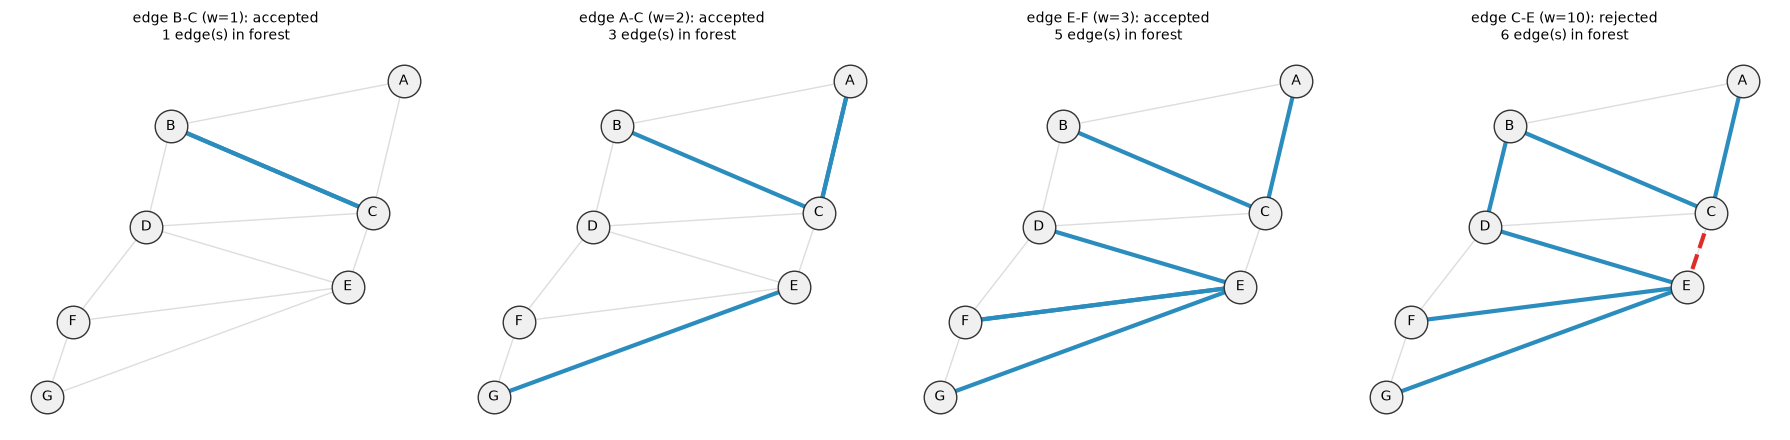

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

G_toy = nx.Graph()
G_toy.add_weighted_edges_from(edges)
pos_toy = nx.spring_layout(G_toy, seed=7)

# Re-run the toy algorithm, capturing a snapshot after each edge is processed.
components = [{v} for v in vertices]
edges_sorted = sorted(edges, key=lambda e: e[2])
accepted_so_far = []
snapshots = []
for u, v, w in edges_sorted:
    accept = not same_component(components, u, v)
    if accept:
        accepted_so_far.append((u, v, w))
        cu = next(c for c in components if u in c)
        cv = next(c for c in components if v in c)
        components.remove(cu)
        components.remove(cv)
        components.append(cu | cv)
    snapshots.append((u, v, w, accept, list(accepted_so_far)))

panel_indices = [0, 2, 4, len(snapshots) - 1]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, idx in zip(axes, panel_indices):
    u, v, w, accept, accepted_edges = snapshots[idx]
    nx.draw_networkx_nodes(G_toy, pos_toy, ax=ax, node_color="#f0f0f0", edgecolors="#333", node_size=550)
    nx.draw_networkx_labels(G_toy, pos_toy, ax=ax, font_size=10)
    nx.draw_networkx_edges(G_toy, pos_toy, ax=ax, edge_color="#dddddd", width=1)
    if accepted_edges:
        nx.draw_networkx_edges(
            G_toy, pos_toy, ax=ax,
            edgelist=[(a, b) for a, b, _ in accepted_edges],
            edge_color="#2b8cbe", width=3,
        )
    verdict = "accepted" if accept else "rejected"
    color = "#2b8cbe" if accept else "#de2d26"
    nx.draw_networkx_edges(
        G_toy, pos_toy, ax=ax, edgelist=[(u, v)],
        edge_color=color, width=3, style="solid" if accept else "dashed",
    )
    ax.set_title(f"edge {u}-{v} (w={w}): {verdict}\n{len(accepted_edges)} edge(s) in forest", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.savefig("forest_growth.png", dpi=110)
plt.show()

Each panel is one moment in the walk-through above: the blue edges
are the forest built so far, and the highlighted edge is the one just
decided. By the last panel, every town is reachable from every other town
through exactly 6 blue edges - the completed spanning tree.

## Implementation

The reference implementation lives in
[`src/kruskal.cpp`](src/kruskal.cpp) - real C++ that sorts the edge list,
then walks it using a **union-find (disjoint-set) structure with path
compression and union by rank**, built from scratch in the same file. It
reads a weighted edge list from stdin and prints every accepted MST edge,
the total weight, and instrumentation (edges considered/accepted/rejected,
final component count, wall-clock time).

We compile it here with `g++` and actually run the resulting binary via
`subprocess` - every number and diagram below comes from a real compiled
program, not a simulation.

> **Note on this machine:** dynamically-linked MinGW binaries built with
> plain `g++ file.cpp -o file.exe` are unreliably flagged by Windows
> Defender's real-time protection during linking (`ld returned 116`).
> Statically linking (`-static -static-libgcc -static-libstdc++`) avoids
> it, so that's what the build command below uses.

In [3]:
import subprocess, pathlib

src_dir = pathlib.Path("src")
exe_path = src_dir / "kruskal.exe"

compile_cmd = [
    "g++", "-O2", "-std=c++17",
    "-static", "-static-libgcc", "-static-libstdc++",
    str(src_dir / "kruskal.cpp"), "-o", str(exe_path),
]
result = subprocess.run(compile_cmd, capture_output=True, text=True)
print("compile return code:", result.returncode)
if result.returncode != 0:
    print(result.stderr)
assert result.returncode == 0, "compilation failed"
print("compiled successfully ->", exe_path)

compile return code: 0
compiled successfully -> src\kruskal.exe


In [4]:
def run_kruskal(V, edge_list):
    # Run the real compiled kruskal binary on an edge list, return parsed stats.
    lines = [f"{V} {len(edge_list)}"]
    for u, v, w in edge_list:
        lines.append(f"{u} {v} {w}")
    input_str = "\n".join(lines)
    proc = subprocess.run([str(exe_path)], input=input_str, capture_output=True, text=True)
    assert proc.returncode == 0, proc.stderr
    mst_edges = []
    stats = {}
    for line in proc.stdout.strip().splitlines():
        if line.startswith("edge:"):
            _, u_s, v_s, w_s = line.split()
            mst_edges.append((int(u_s), int(v_s), int(w_s)))
        elif "=" in line:
            key, val = line.split("=")
            stats[key] = int(val)
    stats["mst_edges"] = mst_edges
    return stats

# Same 7-town example as the hand trace above, letters mapped to 0..6.
letter_to_idx = {c: i for i, c in enumerate("ABCDEFG")}
idx_to_letter = {i: c for c, i in letter_to_idx.items()}
toy_edges_idx = [(letter_to_idx[u], letter_to_idx[v], w) for u, v, w in edges]

real_stats = run_kruskal(7, toy_edges_idx)
print("MST edges (real output from the compiled binary):")
for u, v, w in real_stats["mst_edges"]:
    print(f"  {idx_to_letter[u]}-{idx_to_letter[v]}: {w}")
print(f"\ntotal_weight      = {real_stats['total_weight']}")
print(f"edges_considered  = {real_stats['edges_considered']}")
print(f"edges_accepted    = {real_stats['edges_accepted']}")
print(f"edges_rejected    = {real_stats['edges_rejected']}")
print(f"components        = {real_stats['components']}")
print(f"microseconds      = {real_stats['microseconds']}")

assert real_stats["total_weight"] == toy_total
assert real_stats["components"] == 1
print("\ncorrectness check passed: the real C++ program matches the hand-traced result")

MST edges (real output from the compiled binary):
  B-C: 1
  E-G: 1
  A-C: 2
  D-E: 2
  E-F: 3
  B-D: 5

total_weight      = 14
edges_considered  = 7
edges_accepted    = 6
edges_rejected    = 1
components        = 1
microseconds      = 3

correctness check passed: the real C++ program matches the hand-traced result


### A real weighted graph: original vs. minimum spanning tree

Let's run the real compiled program on a bigger, more visually interesting
random graph and draw the **original graph** next to the **MST it actually
found** - both diagrams below come straight from the compiled binary's
output.

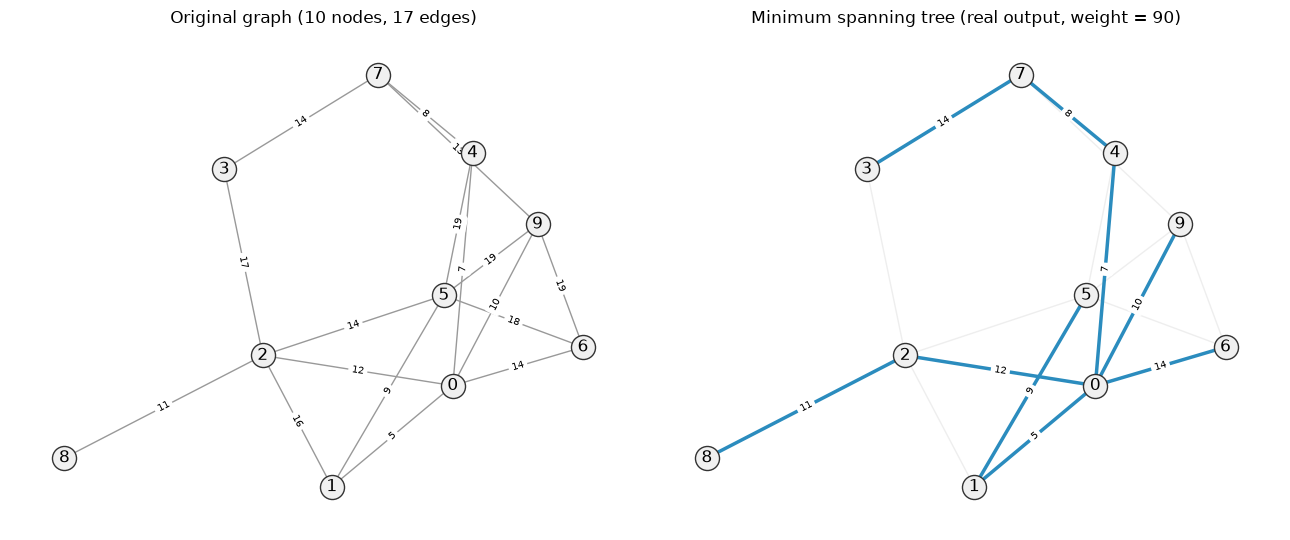

MST total weight: 90
MST edge count:   9 (expected 9)
edges_rejected:   2


In [5]:
import random

def random_connected_graph(n, extra_edges, weight_range=(1, 20), seed=None):
    # Guarantees connectivity by building a random spanning tree first
    # (each new node attaches to a random earlier node), then adds extra
    # random edges on top for texture.
    rng = random.Random(seed)
    order = list(range(n))
    rng.shuffle(order)
    edge_set = set()
    for i in range(1, n):
        j = rng.randint(0, i - 1)
        edge_set.add((min(order[i], order[j]), max(order[i], order[j])))
    attempts = 0
    while len(edge_set) < (n - 1) + extra_edges and attempts < extra_edges * 20:
        u, v = rng.randint(0, n - 1), rng.randint(0, n - 1)
        if u != v:
            edge_set.add((min(u, v), max(u, v)))
        attempts += 1
    return [(u, v, rng.randint(*weight_range)) for u, v in edge_set]

n_nodes = 10
big_edges = random_connected_graph(n_nodes, extra_edges=8, seed=3)

G_big = nx.Graph()
G_big.add_nodes_from(range(n_nodes))
for u, v, w in big_edges:
    G_big.add_edge(u, v, weight=w)

big_stats = run_kruskal(n_nodes, big_edges)
mst_edge_set = {frozenset((u, v)) for u, v, w in big_stats["mst_edges"]}

pos_big = nx.spring_layout(G_big, seed=11)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

nx.draw_networkx_nodes(G_big, pos_big, ax=axes[0], node_color="#f0f0f0", edgecolors="#333")
nx.draw_networkx_labels(G_big, pos_big, ax=axes[0])
nx.draw_networkx_edges(G_big, pos_big, ax=axes[0], edge_color="#999")
edge_labels = {(u, v): G_big[u][v]["weight"] for u, v in G_big.edges()}
nx.draw_networkx_edge_labels(G_big, pos_big, edge_labels=edge_labels, ax=axes[0], font_size=7)
axes[0].set_title(f"Original graph ({n_nodes} nodes, {G_big.number_of_edges()} edges)")
axes[0].axis("off")

nx.draw_networkx_nodes(G_big, pos_big, ax=axes[1], node_color="#f0f0f0", edgecolors="#333")
nx.draw_networkx_labels(G_big, pos_big, ax=axes[1])
nx.draw_networkx_edges(G_big, pos_big, ax=axes[1], edge_color="#eee")
mst_edgelist = [(u, v) for u, v in G_big.edges() if frozenset((u, v)) in mst_edge_set]
nx.draw_networkx_edges(G_big, pos_big, ax=axes[1], edgelist=mst_edgelist, edge_color="#2b8cbe", width=2.5)
nx.draw_networkx_edge_labels(
    G_big, pos_big,
    edge_labels={e: edge_labels[e] for e in mst_edgelist},
    ax=axes[1], font_size=7,
)
axes[1].set_title(f"Minimum spanning tree (real output, weight = {big_stats['total_weight']})")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("mst_vs_original.png", dpi=110)
plt.show()

print(f"MST total weight: {big_stats['total_weight']}")
print(f"MST edge count:   {len(mst_edge_set)} (expected {n_nodes - 1})")
print(f"edges_rejected:   {big_stats['edges_rejected']}")

### Real benchmark: runtime vs. graph size

Now let's actually measure the theory: $O(E \log E)$, dominated by the
sort. We'll generate real connected random graphs of growing size and time
the **real compiled binary** on each.

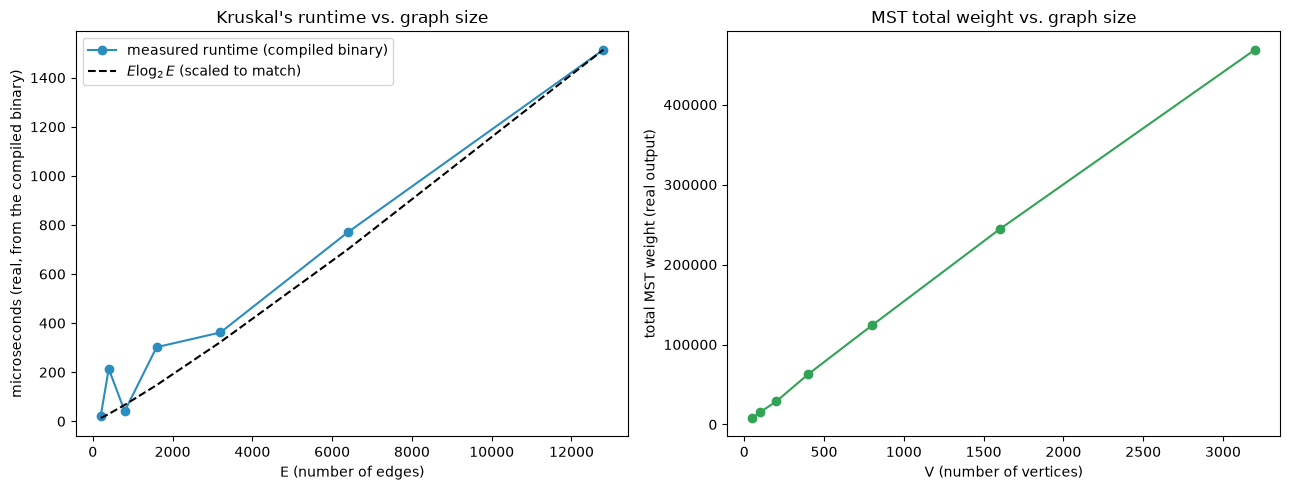

n=   50  E=   199  time=      22 us   E*log2(E)=      1520   mst_weight=    8012
n=  100  E=   399  time=     214 us   E*log2(E)=      3447   mst_weight=   15552
n=  200  E=   799  time=      41 us   E*log2(E)=      7704   mst_weight=   28757
n=  400  E=  1599  time=     302 us   E*log2(E)=     17018   mst_weight=   62763
n=  800  E=  3199  time=     362 us   E*log2(E)=     37247   mst_weight=  123930
n= 1600  E=  6399  time=     771 us   E*log2(E)=     80907   mst_weight=  244203
n= 3200  E= 12799  time=    1514 us   E*log2(E)=    174626   mst_weight=  468748


In [6]:
import numpy as np

sizes = [50, 100, 200, 400, 800, 1600, 3200]
runtimes = []
edge_counts = []
mst_weights = []

for n in sizes:
    graph_edges = random_connected_graph(n, extra_edges=3 * n, weight_range=(1, 1000), seed=42 + n)
    stats_n = run_kruskal(n, graph_edges)
    runtimes.append(stats_n["microseconds"])
    edge_counts.append(len(graph_edges))
    mst_weights.append(stats_n["total_weight"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

edge_arr = np.array(edge_counts)
axes[0].plot(edge_counts, runtimes, "o-", color="#2b8cbe", label="measured runtime (compiled binary)")
scale = runtimes[-1] / (edge_arr[-1] * np.log2(edge_arr[-1]))
axes[0].plot(edge_counts, scale * edge_arr * np.log2(edge_arr), "k--", label=r"$E\log_2 E$ (scaled to match)")
axes[0].set_xlabel("E (number of edges)")
axes[0].set_ylabel("microseconds (real, from the compiled binary)")
axes[0].set_title("Kruskal's runtime vs. graph size")
axes[0].legend()

axes[1].plot(sizes, mst_weights, "o-", color="#31a354")
axes[1].set_xlabel("V (number of vertices)")
axes[1].set_ylabel("total MST weight (real output)")
axes[1].set_title("MST total weight vs. graph size")

plt.tight_layout()
plt.savefig("runtime_vs_size.png", dpi=110)
plt.show()

for n, e, t, w in zip(sizes, edge_counts, runtimes, mst_weights):
    print(f"n={n:5d}  E={e:6d}  time={t:8d} us   E*log2(E)={e * np.log2(e):10.0f}   mst_weight={w:8d}")

The measured runtime tracks $E \log_2 E$ closely across two orders
of magnitude in graph size, exactly as the complexity derivation above
predicts - **the sort dominates**, and the union-find operations riding
alongside it add negligible overhead. MST weight grows roughly linearly
with $V$ here because edge weights are drawn from a fixed random range
regardless of graph size; the runtime curve, not the weight curve, is the
one that confirms the complexity analysis.

## Use cases

- **Network design.** The original motivating problem: laying the
  minimum total length of cable, pipeline, or road to connect a set of
  physical locations - telecom backbones, water/gas pipeline networks,
  and road-network planning all reduce directly to MST when the goal is
  "connect everything as cheaply as possible."
- **Circuit design.** Minimizing total wire length connecting a set of
  pins or components on a chip is a direct MST application (often as a
  building block inside more complex physical-design tools, alongside
  Steiner tree variants for multi-pin nets).
- **Approximation algorithms for harder problems.** MST is a building
  block for a classic **2-approximation algorithm for the metric
  traveling salesman problem** (build an MST, then walk it via a depth-
  first traversal and shortcut repeated visits) - it's a genuinely useful
  practical heuristic, though the approximation ratio itself isn't derived
  here.
- **Clustering.** A perhaps-surprising connection: **single-linkage
  hierarchical clustering** can be derived directly from an MST. Build the
  MST over your data points (with edge weight = distance), then remove the
  $k - 1$ most expensive edges - the graph splits into exactly $k$
  connected components, which are precisely the $k$ single-linkage
  clusters. This is often a faster way to get single-linkage clusters than
  the textbook agglomerative-merging description.

## Limitations & debates

- **Kruskal's is edge-centric, and that has a cost profile.** Sorting all
  $E$ edges is the dominant term, $O(E \log E)$. That's excellent when $E$
  is close to $V$ (sparse graphs), but on a **dense** graph where
  $E$ approaches $V^2$, sorting every edge becomes the bottleneck even
  though most of those edges will never end up mattering.
- **Prim's algorithm is a genuine, still-relevant alternative - not a
  strictly better or worse choice.** Prim's grows a single tree outward
  from one starting vertex, always adding the cheapest edge leaving the
  current tree, implemented with a priority queue/heap in
  $O(E + V \log V)$. It never needs a global sort of all edges, which makes
  it the common preference on **dense graphs**; Kruskal's is often
  preferred on **sparse graphs** or whenever the edge list is already
  naturally available and easy to sort (e.g. edges arriving from a
  database query). Neither dominates the other across all graph shapes -
  which one to reach for is a real, situational implementation decision.
- **MST assumes an undirected graph with well-defined, static edge
  weights.** The analogous problem on a **directed** graph - find the
  minimum-cost set of edges such that every vertex is reachable from a
  designated root - is a genuinely different problem called the **minimum
  arborescence** (or minimum spanning arborescence) problem, and it needs
  a structurally different algorithm, the **Chu-Liu/Edmonds' algorithm**.
  "Just run Kruskal's" does not generalize to directed graphs; treating it
  as if it does is a real and common mistake.
- **MSTs aren't always unique.** When edge weights contain ties, multiple
  distinct spanning trees can share the same minimum total weight -
  Kruskal's returns *one* of them (whichever the tie-breaking order in the
  sort happens to produce), not "the" canonical MST. Code that assumes a
  unique MST (e.g. for reproducible clustering results) needs an explicit,
  documented tie-breaking rule.

## References

- Kruskal, J. B. *On the Shortest Spanning Subtree of a Graph and the
  Traveling Salesman Problem*, Proceedings of the American Mathematical
  Society, 1956 (the original algorithm and paper this tutorial is named
  after).
- Cormen, Leiserson, Rivest & Stein. *Introduction to Algorithms* (CLRS),
  3rd/4th ed., Chapter 23 - the cut property, generic greedy MST
  correctness argument, and both Kruskal's and Prim's algorithms follow
  this treatment.
- `src/kruskal.cpp` in this tutorial's folder - the real, compiled
  implementation (edge sort + from-scratch union-find with path
  compression and union by rank) used for every measurement above.